<a href="https://colab.research.google.com/github/admpvlck/PyTorch/blob/Linear-Regression/Linear_Regression_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Lasso
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Načítanie dát a rozdelenie do X (vstupné premenné) a y (cieľová premenná)
#Loading data and splitting into X (input features) and y (target variable)
data=fetch_california_housing(as_frame=True)
X=data.data
y=data.target

train_X, test_X, train_y, test_y=train_test_split(X, y, test_size=0.2, shuffle=True)

train_X_backup=train_X
train_y_backup=train_y
test_X_backup=test_X
test_y_backup=test_y

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


<Axes: >

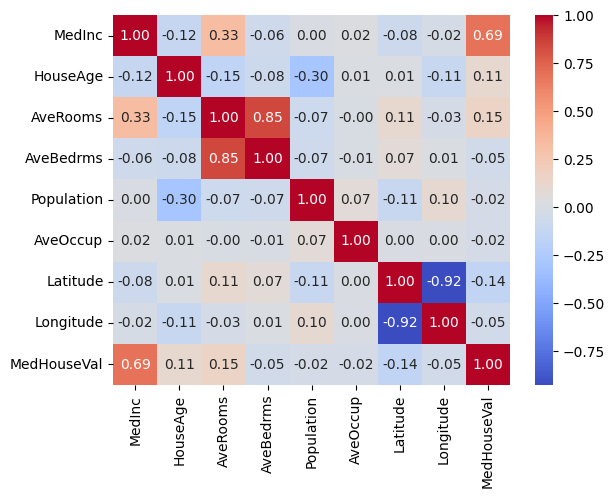

In [ ]:
#Vypísanie najviac korelovaných vstupných premenných s cieľovou premennou
#Printing the input features most correlated with the target variable
print(X.join(y).corr()['MedHouseVal'].sort_values(ascending=False))

corr_mat=X.join(y).corr()
sns.heatmap(corr_mat, annot=True, fmt='.2F', cmap='coolwarm')

In [ ]:
#Výpis score jednotlivých features na základe f_regression s cieľom zistiť, ktoré features sú pre cieľovú premennú dôležité
#Displaying the scores of individual features based on f_regression to determine which features are important for the target variable
selector=SelectKBest(score_func=f_regression, k='all')
selector.fit(train_X, train_y)

f1_scores_df=pd.Series(selector.scores_, index=train_X.columns)
f1_scores_df.sort_values(ascending=False)

,0
MedInc,14900.226444
AveRooms,370.179899
Latitude,360.531024
HouseAge,189.325747
Longitude,32.250848
AveBedrms,29.695381
Population,9.528562
AveOccup,7.865006


In [ ]:
#Výber k features, ktoré sú pre cieľovú premennú y dôležité (na základe f_regression)
#Selecting the top k features that are important for the target variable y (based on f_regression)
selector=SelectKBest(score_func=f_regression, k=5)
train_X_selected=selector.fit_transform(train_X, train_y)
test_X_selected=selector.transform(test_X)

In [ ]:
#Škálovanie
#Scaling
scaler=StandardScaler()
train_X_scaled=scaler.fit_transform(train_X_selected)
test_X_scaled=scaler.transform(test_X_selected)

train_X=torch.tensor(train_X_scaled, dtype=torch.float32)
train_y=torch.tensor(train_y.to_numpy(), dtype=torch.float32).unsqueeze(dim=1)
test_X=torch.tensor(test_X_scaled, dtype=torch.float32)
test_y=torch.tensor(test_y.to_numpy(), dtype=torch.float32).unsqueeze(dim=1)

In [51]:
#Výpis score jednotlivých features na základe Lasso s cieľom zistiť, ktoré features sú pre cieľovú premennú dôležité (vstupné premenné by mali byť preškálované)
#Displaying the scores of individual features based on Lasso to determine which features are important for the target variable
scaler=StandardScaler()
train_X_scaled=scaler.fit_transform(train_X_backup)
test_X_scaled=scaler.transform(test_X_backup)

lasso=Lasso(alpha=0.01)
lasso.fit(train_X_scaled, train_y_backup)

lasso_results=pd.Series(lasso.coef_, index=train_X_backup.columns).sort_values(ascending=False)
lasso_results[lasso_results != 0]

,0
MedInc,0.402803
AveBedrms,0.284080
HouseAge,0.009677
Population,-0.000007
AveOccup,-0.003273
AveRooms,-0.043805
Latitude,-0.405477
Longitude,-0.413444


In [ ]:
#Tvorba modelu
#Creating the model
class LinearRegressionModel(nn.Module):
  def __init__(self, input_shape, output_shape):
    super().__init__()

    self.linear_part=nn.Linear(in_features=input_shape, out_features=output_shape)

  def forward(self, x):
    out=self.linear_part(x)
    return out

#in_shape - počet stĺpcov X; out_shape - počet predikovaných hodnôt
#in_shape - number of columns in X; out_shape - number of predicted values
model=LinearRegressionModel(input_shape=8, output_shape=1)

In [ ]:
#Definovanie loss funkcie a opimizer
#Defining the loss function and optimizer
loss_fn=nn.MSELoss()
optimizer=torch.optim.Adam(params=model.parameters(),
                          lr=0.01)

In [ ]:
#Trénovanie a testovanie modelu
#Training and testing the model
epochs=5000

model_results={'epochs':[],
               'train_loss':[],
               'test_loss':[]}

for epoch in range(0, epochs+1):
  model.train()

  train_y_pred=model(train_X)
  train_loss=loss_fn(train_y_pred, train_y)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model.eval()

  with torch.inference_mode():
    test_y_pred=model(test_X)
    test_loss=loss_fn(test_y_pred, test_y)

  model_results['epochs'].append(epoch)
  model_results['train_loss'].append(train_loss.item())
  model_results['test_loss'].append(test_loss.item())

  if epoch%100==0:
    print('Epoch: {a}; Train loss: {b:.2f}; Test loss: {c:.2f}'.format(a=epoch, b=train_loss, c=test_loss))

Epoch: 0; Train loss: 147729.67; Test loss: 125395.38
Epoch: 100; Train loss: 36.89; Test loss: 33.09
Epoch: 200; Train loss: 5.50; Test loss: 4.69
Epoch: 300; Train loss: 2.92; Test loss: 2.61
Epoch: 400; Train loss: 2.60; Test loss: 2.38
Epoch: 500; Train loss: 2.39; Test loss: 2.21
Epoch: 600; Train loss: 2.20; Test loss: 2.04
Epoch: 700; Train loss: 2.02; Test loss: 1.89
Epoch: 800; Train loss: 1.86; Test loss: 1.75
Epoch: 900; Train loss: 1.71; Test loss: 1.62
Epoch: 1000; Train loss: 1.58; Test loss: 1.50
Epoch: 1100; Train loss: 1.46; Test loss: 1.40
Epoch: 1200; Train loss: 1.35; Test loss: 1.31
Epoch: 1300; Train loss: 1.26; Test loss: 1.22
Epoch: 1400; Train loss: 1.17; Test loss: 1.15
Epoch: 1500; Train loss: 1.10; Test loss: 1.08
Epoch: 1600; Train loss: 1.03; Test loss: 1.02
Epoch: 1700; Train loss: 0.97; Test loss: 0.96
Epoch: 1800; Train loss: 0.92; Test loss: 0.91
Epoch: 1900; Train loss: 0.87; Test loss: 0.87
Epoch: 2000; Train loss: 0.83; Test loss: 0.84
Epoch: 2100; 

In [ ]:
#Predikcia y pomocou natrénovaného modelu
#Predicting y using the trained model
model.eval()

with torch.inference_mode():
  y_pred=model(test_X)

In [ ]:
#Vytvorenie dataframe pre porovnanie predikcie so skutočnými hodnotami
#Creating a dataframe to compare predictions with actual values
comp_data=pd.DataFrame({
    'MedHouseVal_pred':y_pred[:, 0],
    'MedHouseVal_real_data':test_y[:, 0]
})

comp_data

,MedHouseVal_pred,MedHouseVal_real_data
0,1.744697,2.729
1,0.579346,0.720
2,3.201385,2.739
3,2.211818,1.591
4,3.409384,3.977
...,...,...
4123,2.283102,1.339
4124,2.671885,2.191
4125,2.341541,1.304
4126,1.962470,1.952


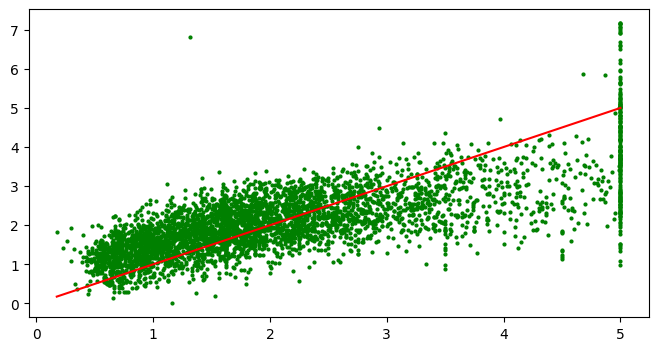

In [ ]:
#Grafické znázornenie výsledkov (1)
#Graphical visualization of results (1)
#True data vs Prediction
plt.figure(figsize=(8, 4))

plt.scatter(test_y[:, 0], y_pred[:, 0], c='b', s=4)
plt.plot([test_y[:, 0].min(), test_y[:, 0].max()],
         [test_y[:, 0].min(), test_y[:, 0].max()],
         c='r')
plt.show()

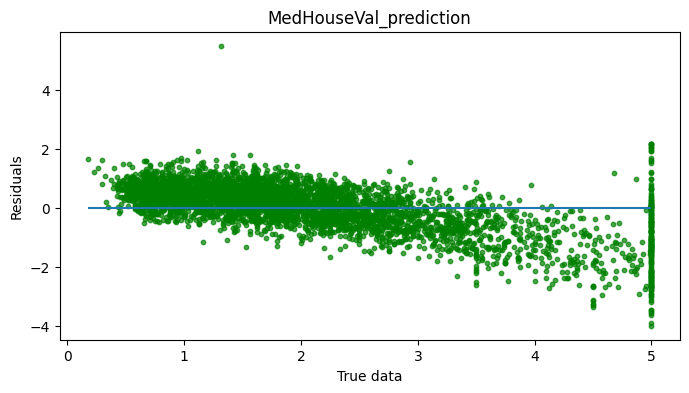

In [ ]:
#Grafické znázornenie výsledkov (2)
#Graphical visualization of results (2)
#Residuals
plt.figure(figsize=(8, 4))
residuals=y_pred[:, 0]-test_y[:, 0]

plt.scatter(test_y[:, 0], residuals, alpha=0.7, s=10, c='green')
plt.hlines(0, min(test_y[:, 0]), max(test_y[:, 0]))
plt.title('MedHouseVal_prediction')
plt.xlabel('True data')
plt.ylabel('Residuals')
plt.show()

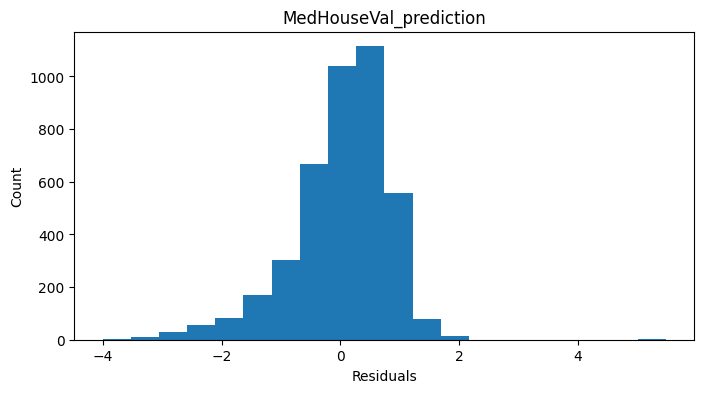

In [ ]:
#Grafické znázornenie výsledkov (3)
#Graphical visualization of results (3)
#Histogram - residuals
plt.figure(figsize=(8, 4))
residuals=y_pred[:, 0]-test_y[:, 0]

plt.hist(residuals, bins=20)
plt.title('MedHouseVal_prediction')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

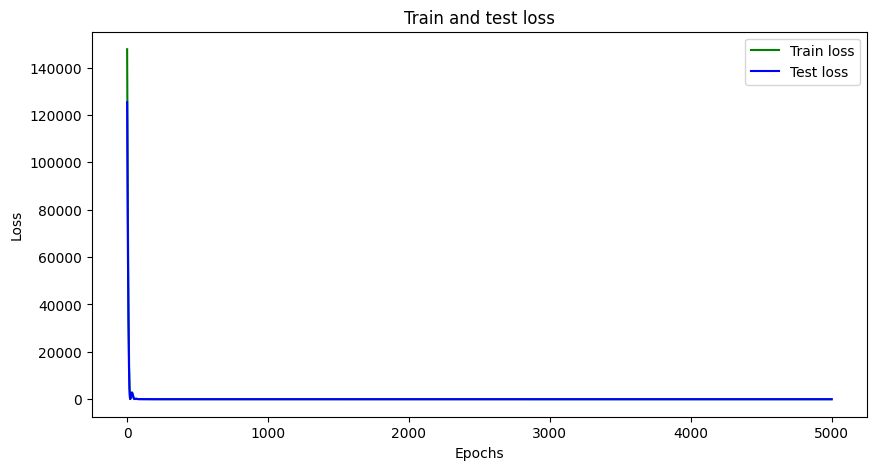

In [ ]:
#Grafické znázornenie výsledkov (4)
#Graphical visualization of results (4)
#Train loss, test loss
plt.figure(figsize=(10, 5))

plt.plot(model_results['epochs'], model_results['train_loss'], label='Train loss', c='green')
plt.plot(model_results['epochs'], model_results['test_loss'], label='Test loss', c='blue')
plt.legend(loc='best')
plt.title('Train and test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()